# Flagging Vendor invoices for manual review

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('../data/inventory.db')

In [3]:
tables = pd.read_sql_query("select name from sqlite_master where type='table'", conn)
for table in tables['name']:
    print(f'Table name: {table}')
    display(pd.read_sql(f'select * from {table} limit 5', conn))

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [4]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

In [5]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay
from vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [6]:
df = pd.read_sql_query("""
with purchase_agg as (
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)

select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay

from vendor_invoice vi
left join purchase_agg pa
on vi.PONumber = pa.PONumber
""", conn)

In [7]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [8]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [9]:
def create_invoice_risk_label(row):
    if(abs(row['invoice_dollars'] - row['total_item_dollars']) >5):
        return 1

    if row['avg_receiving_delay'] > 10:
        return 1

    return 0
df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

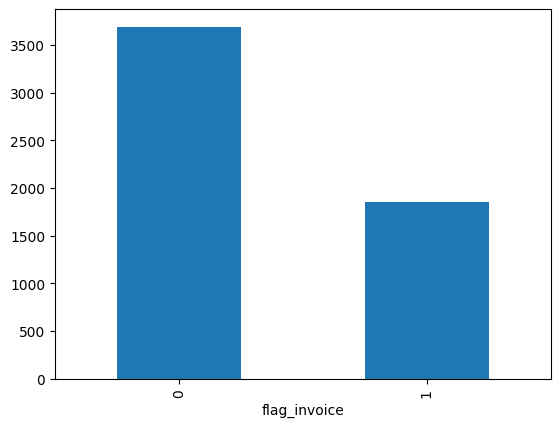

In [10]:
df['flag_invoice'].value_counts().plot(kind='bar')

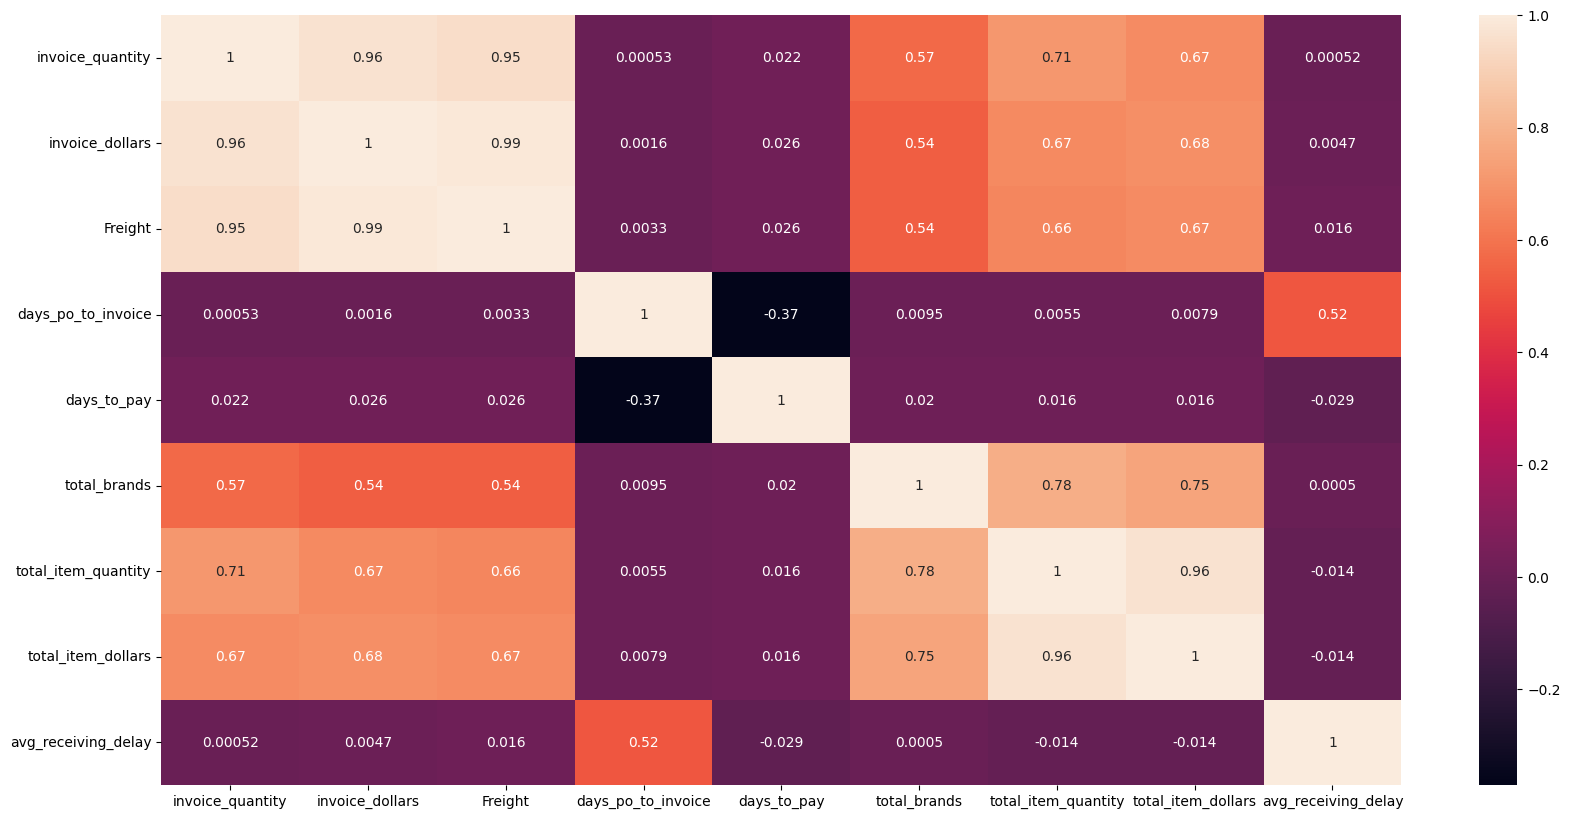

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [12]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [13]:
significant_features = []
non_significant_features = []
results = []

In [14]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [15]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metrics].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
    flagged[metric].dropna(),
    normal[metric].dropna(),
    equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        'metric':metric,
        'flagged_mean':flagged_mean.round(2),
        'normal_mean':normal_mean.round(2),
        'p_value':p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

In [16]:
non_significant_features

['days_to_pay', 'total_brands']

In [17]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [18]:
X = df[['invoice_quantity', 'invoice_dollars','Freight', 'days_po_to_invoice','total_item_quantity','total_item_dollars', 'avg_receiving_delay']]
y = df['flag_invoice']

In [19]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)*100

    print(f'\n{model_name} Performance:')
    print(f'mae : {mae:.2f}')
    print(f'rmse : {rmse:.2f}')
    print(f'r2 : {r2:.2f}%')

In [25]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
mae : 0.26
rmse : 0.26
r2 : -15.12%

Decision Tree Classifier Performance:
mae : 0.05
rmse : 0.05
r2 : 77.29%

Random Forest Classifier Performance:
mae : 0.04
rmse : 0.04
r2 : 80.48%


In [26]:
model3.feature_importances_

array([0.10668727, 0.10055568, 0.10323929, 0.02603186, 0.15331893,
       0.20578767, 0.3043793 ])

In [27]:
feature_importance = pd.DataFrame({
    'feature':X_train.columns,
    'importance':model3.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
6,avg_receiving_delay,0.304379
5,total_item_dollars,0.205788
4,total_item_quantity,0.153319
0,invoice_quantity,0.106687
2,Freight,0.103239
1,invoice_dollars,0.100556
3,days_po_to_invoice,0.026032


In [28]:
X = df[['invoice_quantity','invoice_dollars','Freight', 'total_item_quantity','total_item_dollars']]
y = df['flag_invoice']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance:
mae : 0.12
rmse : 0.12
r2 : 49.01%


In [30]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[None, 4,5,6],
    'min_samples_split':[2,3,5],
    'min_samples_leaf':[1,2,5],
    'criterion':['gini','entropy']
}

In [31]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring = scorer,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier Performance:
mae : 0.11
rmse : 0.11
r2 : 50.60%


In [38]:
from sklearn.metrics import confusion_matrix

In [41]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[713, 112],
       [ 12, 272]], dtype=int64)

In [42]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[706, 109],
       [ 19, 275]], dtype=int64)

In [44]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}